# Train TRRUST Classifiers

Train binary (Relationship vs None) and ternary (Activation vs Repression vs None)
classifiers on TRRUST transcription factor–target gene relationships using
pre-computed scGPT gene embeddings.

In [9]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, TensorDataset

from scfm_utils.scgpt import load_average_gene_embeddings
from scfm_utils.trrust import (
    BINARY_LABEL_NAMES,
    BINARY_LABELS,
    TERNARY_LABEL_NAMES,
    TERNARY_LABELS,
    TRRClassifierModel,
    load_binary_trrust_data,
    load_ternary_trrust_data,
)

## Configuration

In [ ]:
EMBEDDINGS_PATH = Path("../data/embeddings/scgpt_human_cd20.h5ad")
TRRUST_PATH = Path("../data/trrust_rawdata.human.tsv")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
LR = 1e-3
BINARY_EPOCHS = 20
TERNARY_EPOCHS = 24

print(f"Device: {DEVICE}")
print(f"Embeddings: {EMBEDDINGS_PATH}")
print(f"TRRUST: {TRRUST_PATH}")

Device: cuda
Embeddings: ../data/embeddings/scgpt_human_cd20.h5ad
TRRUST: ../data/trrust_rawdata.human.tsv


## Load model and data

In [11]:
adata = load_average_gene_embeddings(EMBEDDINGS_PATH)
gene_embeddings = {gene: adata.X[i] for i, gene in enumerate(adata.obs_names)}
embsize = adata.X.shape[1]

binary_data = load_binary_trrust_data(TRRUST_PATH, gene_embeddings)
ternary_data = load_ternary_trrust_data(TRRUST_PATH, gene_embeddings)

print(f"Cell type: {adata.uns['cell_type']!r}")
print(f"Gene embeddings: {len(gene_embeddings)} genes, {embsize}d")
print(f"\nBinary samples: {len(binary_data.records)}")
for label_id, name in BINARY_LABEL_NAMES.items():
    print(f"  {name}: {(binary_data.labels == label_id).sum()}")
print(f"\nTernary samples: {len(ternary_data.records)}")
for label_id, name in TERNARY_LABEL_NAMES.items():
    print(f"  {name}: {(ternary_data.labels == label_id).sum()}")

Cell type: 'CD20+ B cells'
Gene embeddings: 10856 genes, 512d

Binary samples: 8100
  None: 4050
  Relationship: 4050

Ternary samples: 3147
  Activation: 1265
  Repression: 833
  None: 1049


## Train Binary TRRUST Classifier

### 90/10 Stratified Train-Test Split

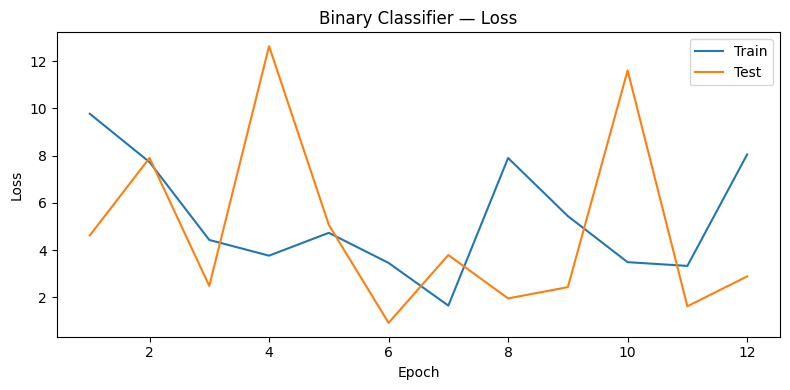

              precision    recall  f1-score   support

        None       0.89      0.08      0.15       405
Relationship       0.52      0.99      0.68       405

    accuracy                           0.54       810
   macro avg       0.71      0.54      0.42       810
weighted avg       0.71      0.54      0.42       810



In [12]:
tf_tensor = torch.from_numpy(binary_data.tf_embeddings).float()
tgt_tensor = torch.from_numpy(binary_data.target_embeddings).float()
label_tensor = torch.from_numpy(binary_data.labels).long()

n_classes = len(BINARY_LABELS)

train_idx, test_idx = train_test_split(
    np.arange(len(label_tensor)), test_size=0.1, stratify=binary_data.labels, random_state=42
)

train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

train_losses, test_losses = [], []
for epoch in range(BINARY_EPOCHS):
    classifier.train()
    epoch_loss = 0.0
    for tf_b, tgt_b, lbl_b in train_loader:
        tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
        logits = classifier(tf_b, tgt_b)
        loss = criterion(logits, lbl_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(lbl_b)
    train_losses.append(epoch_loss / len(train_idx))

    classifier.eval()
    test_loss = 0.0
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            test_loss += criterion(logits, lbl_b).item() * len(lbl_b)
    test_losses.append(test_loss / len(test_idx))

epochs = range(1, BINARY_EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Binary Classifier — Loss")
plt.legend()
plt.tight_layout()
plt.show()

classifier.eval()
all_preds = []
with torch.no_grad():
    for tf_b, tgt_b, lbl_b in test_loader:
        logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
all_preds = torch.cat(all_preds).numpy()

target_names = [BINARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(binary_data.labels[test_idx], all_preds, target_names=target_names))

### Stratified 5-Fold Cross-Validation (no class weights)

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = np.zeros(len(label_tensor), dtype=np.int64)

for fold, (train_idx, test_idx) in enumerate(skf.split(tf_tensor, label_tensor)):
    train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
    test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(BINARY_EPOCHS):
        classifier.train()
        for tf_b, tgt_b, lbl_b in train_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            loss = criterion(logits, lbl_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    classifier.eval()
    fold_preds = []
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
            fold_preds.append(logits.argmax(dim=1).cpu())
    fold_preds = torch.cat(fold_preds).numpy()
    all_preds[test_idx] = fold_preds

    fold_acc = (fold_preds == binary_data.labels[test_idx]).mean()
    print(f"Fold {fold + 1}: accuracy={fold_acc:.3f} (n={len(test_idx)})")

target_names = [BINARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(binary_data.labels, all_preds, target_names=target_names))

Fold 1: accuracy=0.501 (n=1620)
Fold 2: accuracy=0.529 (n=1620)
Fold 3: accuracy=0.500 (n=1620)
Fold 4: accuracy=0.654 (n=1620)
Fold 5: accuracy=0.500 (n=1620)
              precision    recall  f1-score   support

        None       0.55      0.37      0.45      4050
Relationship       0.53      0.70      0.60      4050

    accuracy                           0.54      8100
   macro avg       0.54      0.54      0.52      8100
weighted avg       0.54      0.54      0.52      8100



## Train Ternary TRRUST Classifier

### 90/10 Stratified Train-Test Split

Class weights:
  Activation: 0.829 (n=1265)
  Repression: 1.259 (n=833)
  None: 1.000 (n=1049)


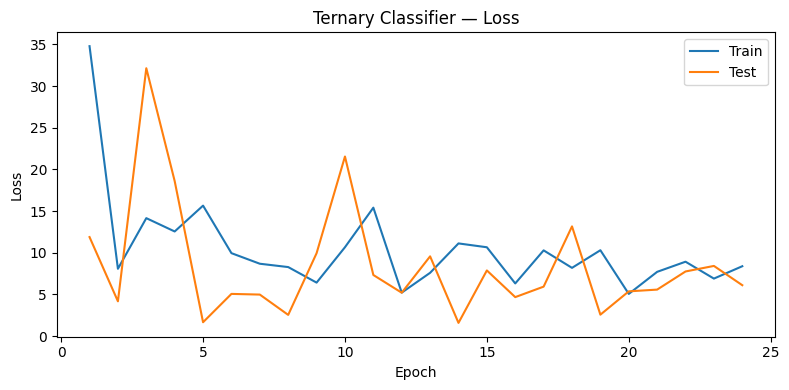

              precision    recall  f1-score   support

  Activation       0.00      0.00      0.00       127
  Repression       0.26      1.00      0.42        83
        None       0.00      0.00      0.00       105

    accuracy                           0.26       315
   macro avg       0.09      0.33      0.14       315
weighted avg       0.07      0.26      0.11       315



In [14]:
tf_tensor = torch.from_numpy(ternary_data.tf_embeddings).float()
tgt_tensor = torch.from_numpy(ternary_data.target_embeddings).float()
label_tensor = torch.from_numpy(ternary_data.labels).long()

n_classes = len(TERNARY_LABELS)
class_counts = torch.bincount(label_tensor, minlength=n_classes).float()
class_weights = (len(label_tensor) / (n_classes * class_counts)).to(DEVICE)

print("Class weights:")
for label_id, name in TERNARY_LABEL_NAMES.items():
    print(f"  {name}: {class_weights[label_id]:.3f} (n={int(class_counts[label_id])})")

train_idx, test_idx = train_test_split(
    np.arange(len(label_tensor)), test_size=0.1, stratify=ternary_data.labels, random_state=42
)

train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

train_losses, test_losses = [], []
for epoch in range(TERNARY_EPOCHS):
    classifier.train()
    epoch_loss = 0.0
    for tf_b, tgt_b, lbl_b in train_loader:
        tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
        logits = classifier(tf_b, tgt_b)
        loss = criterion(logits, lbl_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(lbl_b)
    train_losses.append(epoch_loss / len(train_idx))

    classifier.eval()
    test_loss = 0.0
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            test_loss += criterion(logits, lbl_b).item() * len(lbl_b)
    test_losses.append(test_loss / len(test_idx))

epochs = range(1, TERNARY_EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ternary Classifier — Loss")
plt.legend()
plt.tight_layout()
plt.show()

classifier.eval()
all_preds = []
with torch.no_grad():
    for tf_b, tgt_b, lbl_b in test_loader:
        logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
all_preds = torch.cat(all_preds).numpy()

target_names = [TERNARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(ternary_data.labels[test_idx], all_preds, target_names=target_names))

### Stratified 5-Fold Cross-Validation (using class weights)

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = np.zeros(len(label_tensor), dtype=np.int64)

for fold, (train_idx, test_idx) in enumerate(skf.split(tf_tensor, label_tensor)):
    train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
    test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(TERNARY_EPOCHS):
        classifier.train()
        for tf_b, tgt_b, lbl_b in train_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            loss = criterion(logits, lbl_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    classifier.eval()
    fold_preds = []
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
            fold_preds.append(logits.argmax(dim=1).cpu())
    fold_preds = torch.cat(fold_preds).numpy()
    all_preds[test_idx] = fold_preds

    fold_acc = (fold_preds == ternary_data.labels[test_idx]).mean()
    print(f"Fold {fold + 1}: accuracy={fold_acc:.3f} (n={len(test_idx)})")

target_names = [TERNARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(ternary_data.labels, all_preds, target_names=target_names))

Fold 1: accuracy=0.402 (n=630)
Fold 2: accuracy=0.344 (n=630)
Fold 3: accuracy=0.370 (n=629)
Fold 4: accuracy=0.273 (n=629)
Fold 5: accuracy=0.366 (n=629)
              precision    recall  f1-score   support

  Activation       0.43      0.32      0.37      1265
  Repression       0.28      0.35      0.31       833
        None       0.35      0.40      0.37      1049

    accuracy                           0.35      3147
   macro avg       0.35      0.35      0.35      3147
weighted avg       0.36      0.35      0.35      3147

